In [1]:
import numpy as np
import time
from tqdm.auto import tqdm, trange

from robofin.robots import FrankaRobot, FrankaGripper
from robofin.bullet import Bullet, BulletController

from pathlib import Path
from geometrout.primitive import Cuboid, Cylinder
from geometrout.transform import SE3

import pickle
from dataclasses import dataclass, field
from typing import List, Union, Optional, Dict
import argparse
import sys

import torch
from utils import FrankaSampler
from mpinets.model import MotionPolicyNetwork
from mpinets.geometry import construct_mixed_point_cloud
from mpinets.utils import normalize_franka_joints, unnormalize_franka_joints
from mpinets.metrics import Evaluator
from mpinets.mpinets_types import PlanningProblem, ProblemSet
import trimesh
import meshcat
import urchin

END_EFFECTOR_FRAME = "right_gripper"
NUM_ROBOT_POINTS = 2048
NUM_OBSTACLE_POINTS = 4096
NUM_TARGET_POINTS = 128
MAX_ROLLOUT_LENGTH = 150


def get_tool_parameters(problem, device="cuda:0"):
    """
    Extract tool parameters for either single primitive or composite tools
    Returns tensors for compatibility with sampling functions
    """
    if problem.tool is None:
        # No tool
        return {
            "is_composite": False,
            "tool_dims": [0.0, 0.0, 0.0],
            "tool_offsets": [0.0, 0.0, 0.0],
            "tool_quats": [1.0, 0.0, 0.0, 0.0],
            "tool_num_primitives": 0,
        }

    primitives = problem.tool.primitives
    if len(primitives) == 1:
        # Single primitive tool
        primitive = primitives[0]
        return {
            "is_composite": False,
            "tool_dims": primitive["dims"],
            "tool_offsets": primitive["offset"],
            "tool_quats": primitive["offset_quaternion"],
            "tool_num_primitives": 1,
        }
    else:
        # Composite tool with multiple primitives
        tool_dims = []
        tool_offsets = []
        tool_quats = []

        for primitive in primitives:
            tool_dims.append(primitive["dims"])
            tool_offsets.append(primitive["offset"])
            tool_quats.append(primitive["offset_quaternion"])

        return {
            "is_composite": True,
            "tool_dims": tool_dims,
            "tool_offsets": tool_offsets,
            "tool_quats": tool_quats,
            "tool_num_primitives": len(primitives),
        }


def sample_robot_points(gpu_fk_sampler, config, tool_params, num_points):
    """Sample robot points with appropriate method based on tool type"""
    # Convert to tensors
    device = config.device
    dtype = config.dtype

    # For both composite and single primitive, we use sample_composite
    # For single primitive, wrap parameters in lists
    if tool_params["is_composite"] and tool_params["tool_num_primitives"] > 0:
        tool_dims = tool_params["tool_dims"]
        tool_offsets = tool_params["tool_offsets"]
        tool_quats = tool_params["tool_quats"]
    else:
        # Single primitive - wrap in lists
        if tool_params["tool_num_primitives"] > 0:
            tool_dims = [tool_params["tool_dims"]]
            tool_offsets = [tool_params["tool_offsets"]]
            tool_quats = [tool_params["tool_quats"]]
        else:
            # No tool
            tool_dims = []
            tool_offsets = []
            tool_quats = []

    tool_dims_tensor = torch.tensor(tool_dims, dtype=dtype, device=device)
    tool_offsets_tensor = torch.tensor(tool_offsets, dtype=dtype, device=device)
    tool_quats_tensor = torch.tensor(tool_quats, dtype=dtype, device=device)
    tool_num_primitives_tensor = torch.tensor(
        len(tool_dims), dtype=torch.long, device=device
    )

    return gpu_fk_sampler.sample_composite(
        config,
        tool_dims_tensor,
        tool_offsets_tensor,
        tool_quats_tensor,
        tool_num_primitives_tensor,
        num_points,
    )


def sample_target_points(gpu_fk_sampler, pose, tool_params, num_points):
    """Sample target points with appropriate method based on tool type"""
    # Convert to tensors
    device = pose.device
    dtype = pose.dtype

    # For both composite and single primitive, we use sample_composite_end_effector
    # For single primitive, wrap parameters in lists
    if tool_params["is_composite"] and tool_params["tool_num_primitives"] > 0:
        tool_dims = tool_params["tool_dims"]
        tool_offsets = tool_params["tool_offsets"]
        tool_quats = tool_params["tool_quats"]
    else:
        # Single primitive - wrap in lists
        if tool_params["tool_num_primitives"] > 0:
            tool_dims = [tool_params["tool_dims"]]
            tool_offsets = [tool_params["tool_offsets"]]
            tool_quats = [tool_params["tool_quats"]]
        else:
            # No tool
            tool_dims = []
            tool_offsets = []
            tool_quats = []

    tool_dims_tensor = torch.tensor(tool_dims, dtype=dtype, device=device)
    tool_offsets_tensor = torch.tensor(tool_offsets, dtype=dtype, device=device)
    tool_quats_tensor = torch.tensor(tool_quats, dtype=dtype, device=device)
    tool_num_primitives_tensor = torch.tensor(
        len(tool_dims), dtype=torch.long, device=device
    )

    return gpu_fk_sampler.sample_composite_end_effector(
        pose,
        tool_dims_tensor,
        tool_offsets_tensor,
        tool_quats_tensor,
        tool_num_primitives_tensor,
        num_points,
    )


def make_point_cloud_from_problem(
    q0: torch.Tensor,
    target: SE3,
    obstacle_points: np.ndarray,
    fk_sampler: FrankaSampler,
    tool_params: dict,
) -> torch.Tensor:
    robot_points = sample_robot_points(
        fk_sampler, q0, tool_params, NUM_ROBOT_POINTS
    ).squeeze(0)

    target_points = sample_target_points(
        fk_sampler,
        torch.as_tensor(target.matrix).type_as(robot_points).unsqueeze(0),
        tool_params,
        NUM_TARGET_POINTS,
    ).squeeze(0)

    xyz = torch.cat(
        (
            torch.zeros(NUM_ROBOT_POINTS, 4),
            torch.ones(NUM_OBSTACLE_POINTS, 4),
            2 * torch.ones(NUM_TARGET_POINTS, 4),
        ),
        dim=0,
    )
    xyz[:NUM_ROBOT_POINTS, :3] = robot_points.float()
    random_obstacle_indices = np.random.choice(
        len(obstacle_points), size=NUM_OBSTACLE_POINTS, replace=False
    )
    xyz[
        NUM_ROBOT_POINTS : NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS,
        :3,
    ] = torch.as_tensor(obstacle_points[random_obstacle_indices, :3]).float()
    xyz[
        NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS :,
        :3,
    ] = target_points.float()
    return xyz


def make_point_cloud_from_primitives(
    q0: torch.Tensor,
    target: SE3,
    obstacles: List[Union[Cuboid, Cylinder]],
    fk_sampler: FrankaSampler,
    tool_params: dict,
) -> torch.Tensor:
    """
    Creates the pointcloud of the scene, including the target and the robot. When performing
    a rollout, the robot points will be replaced based on the model's prediction

    :param q0 torch.Tensor: The starting configuration (dimensions [1 x 7])
    :param target SE3: The target pose in the `right_gripper` frame
    :param obstacles List[Union[Cuboid, Cylinder]]: The obstacles in the scene
    :param fk_sampler FrankaSampler: A sampler that produces points on the robot's surface
    :param tool_params dict: Tool parameters from get_tool_parameters
    :rtype torch.Tensor: The pointcloud (dimensions
                         [1 x NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS + NUM_TARGET_POINTS x 4])
    """
    obstacle_points = construct_mixed_point_cloud(obstacles, NUM_OBSTACLE_POINTS)
    robot_points = sample_robot_points(
        fk_sampler, q0, tool_params, NUM_ROBOT_POINTS
    ).squeeze(0)

    target_points = sample_target_points(
        fk_sampler,
        torch.as_tensor(target.matrix).type_as(robot_points).unsqueeze(0),
        tool_params,
        NUM_TARGET_POINTS,
    ).squeeze(0)

    xyz = torch.cat(
        (
            torch.zeros(NUM_ROBOT_POINTS, 4),
            torch.ones(NUM_OBSTACLE_POINTS, 4),
            2 * torch.ones(NUM_TARGET_POINTS, 4),
        ),
        dim=0,
    )
    xyz[:NUM_ROBOT_POINTS, :3] = robot_points.float()
    xyz[
        NUM_ROBOT_POINTS : NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS,
        :3,
    ] = torch.as_tensor(obstacle_points[:, :3]).float()
    xyz[
        NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS :,
        :3,
    ] = target_points.float()
    return xyz

pybullet build time: Jan 29 2025 23:19:57


In [14]:
# Load a problem set
import mpinets.mpinets_types as mpinets_types
problem_path = Path(
    "/home/zippingsugar/Programs/motion-policy-networks/problems/tabletop_tools_complex_neutral_50.pkl"
)
import sys
sys.modules["data_pipeline.environments.base_environment"] = mpinets_types
sys.modules["mpinets.data_pipeline.environments.base_environment"] = mpinets_types

# Check if the problem file exists
if not problem_path.exists():
    print(f"Problem file {problem_path} does not exist.")
else:
    # Load the problem set
    with open(problem_path, "rb") as f:
        all_problems = pickle.load(f)
    
    
    environment_type = "tabletop"
    problem_type = "neutral_start"
    problem_index = 1
    problem = all_problems[environment_type][problem_type][problem_index]


In [15]:
# Initialize the FK sampler
fk_sampler = FrankaSampler("cuda:0", use_cache=True)

# Get tool parameters
tool_params = get_tool_parameters(problem)

print(f"Tool parameters: {tool_params}")

Tool parameters: {'is_composite': True, 'tool_dims': [[0.03154538530533421, 0.03099863602332761, 0.09898649310221569], [0.14420861778188926, 0.028207928077365677, 0.030321106920545047]], 'tool_offsets': [[0, 0, 0.049493246551107845], [-0.009288912668281538, 0.0028616273988365665, 0.10414704656248822]], 'tool_quats': [[0.9958887563854462, -0.01373753191082017, 0.0770631116989125, -0.04558664209315497], [0.9981381000511457, -0.03666567006179611, -0.048605974910845375, -0.0036634776067064716]], 'tool_num_primitives': 2}


In [16]:
# TODO construct robot point cloud
# Construct robot point cloud
q0_tensor = torch.as_tensor(problem.q0).unsqueeze(0).cuda()

# Sample robot points
robot_points = sample_robot_points(
    fk_sampler, q0_tensor, tool_params, NUM_ROBOT_POINTS
).squeeze(0)

print(f"Robot points shape: {robot_points.shape}")
print(f"First few robot points: {robot_points[:5]}")

Robot points shape: torch.Size([2048, 3])
First few robot points: tensor([[ 2.9663e-01,  9.6369e-02,  4.2277e-01],
        [ 1.2499e-02,  2.9895e-02,  3.1802e-04],
        [ 1.6216e-02,  2.6442e-02,  1.4100e-01],
        [ 3.6157e-01,  1.0699e-01,  5.7451e-01],
        [-1.3453e-01,  4.9336e-03,  6.1324e-01]], device='cuda:0')


In [17]:
# Construct target point cloud with correct data type
print(f"Target pose matrix: {problem.target.matrix}")
target_pose = problem.target.matrix

# Mpve the target position x + 0.4, y-0.2, z - 0.1 for better visibility
target_pose[0, 3] += 0.3
target_pose[1, 3] -= 0.2
target_pose[2, 3] -= 0.1

target_pose_tensor = (
    torch.as_tensor(target_pose, dtype=torch.float32).cuda().unsqueeze(0)
)

# Sample target points
target_points = sample_target_points(
    fk_sampler, target_pose_tensor, tool_params, NUM_TARGET_POINTS
).squeeze(0)

print(f"Target points shape: {target_points.shape}")
print(f"First few target points: {target_points[:5]}")

Target pose matrix: [[ 0.86561753  0.45206742 -0.21527038  0.4513345 ]
 [ 0.47810528 -0.87396632  0.08716768  0.25780495]
 [-0.14873339 -0.17837578 -0.97265639  0.35484148]
 [ 0.          0.          0.          1.        ]]
Target points shape: torch.Size([128, 3])
First few target points: tensor([[ 0.7523,  0.0612,  0.2559],
        [ 0.7728,  0.0762,  0.3363],
        [ 0.7303,  0.0866,  0.3376],
        [ 0.8038, -0.0307,  0.2743],
        [ 0.7400,  0.1451,  0.3294]], device='cuda:0')


In [18]:
# Construct obstacle point cloud
if (
    hasattr(problem, "obstacle_point_cloud")
    and problem.obstacle_point_cloud is not None
):
    # Use pre-computed obstacle point cloud
    obstacle_points = problem.obstacle_point_cloud
    print(
        f"Using pre-computed obstacle point cloud with shape: {obstacle_points.shape}"
    )
else:
    # Sample from primitive obstacles
    from mpinets.geometry import construct_mixed_point_cloud

    obstacle_points = construct_mixed_point_cloud(
        problem.obstacles, NUM_OBSTACLE_POINTS
    )
    print(f"Constructed obstacle point cloud with shape: {obstacle_points.shape}")

print(f"First few obstacle points: {obstacle_points[:5]}")

Constructed obstacle point cloud with shape: (4096, 4)
First few obstacle points: [[ 0.94448601  0.2361299   0.41183617  7.        ]
 [ 0.62837551 -0.23634797 -0.02        5.        ]
 [ 0.92193642 -0.43785648  0.17343596  1.        ]
 [-0.10376641 -0.15013482 -0.02        6.        ]
 [ 0.37603369  0.02447912  0.12319503  8.        ]]


In [19]:
# Now let's create the complete point cloud as done in run_inference.py
def create_complete_point_cloud(robot_pts, obstacle_pts, target_pts):
    """Create the complete point cloud with labels"""
    xyz = torch.cat(
        (
            torch.zeros(NUM_ROBOT_POINTS, 4),
            torch.ones(NUM_OBSTACLE_POINTS, 4),
            2 * torch.ones(NUM_TARGET_POINTS, 4),
        ),
        dim=0,
    )
    xyz[:NUM_ROBOT_POINTS, :3] = robot_pts.float()

    # For obstacle points, if we have more than needed, sample randomly
    if len(obstacle_pts) > NUM_OBSTACLE_POINTS:
        random_indices = np.random.choice(
            len(obstacle_pts), size=NUM_OBSTACLE_POINTS, replace=False
        )
        obstacle_pts_sampled = obstacle_pts[random_indices]
    else:
        obstacle_pts_sampled = obstacle_pts

    xyz[NUM_ROBOT_POINTS : NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS, :3] = (
        torch.as_tensor(obstacle_pts_sampled[:, :3]).float()
    )
    xyz[NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS :, :3] = target_pts.float()

    return xyz


# Create the complete point cloud
complete_point_cloud = create_complete_point_cloud(
    robot_points, obstacle_points, target_points
)
print(f"Complete point cloud shape: {complete_point_cloud.shape}")

Complete point cloud shape: torch.Size([6272, 4])


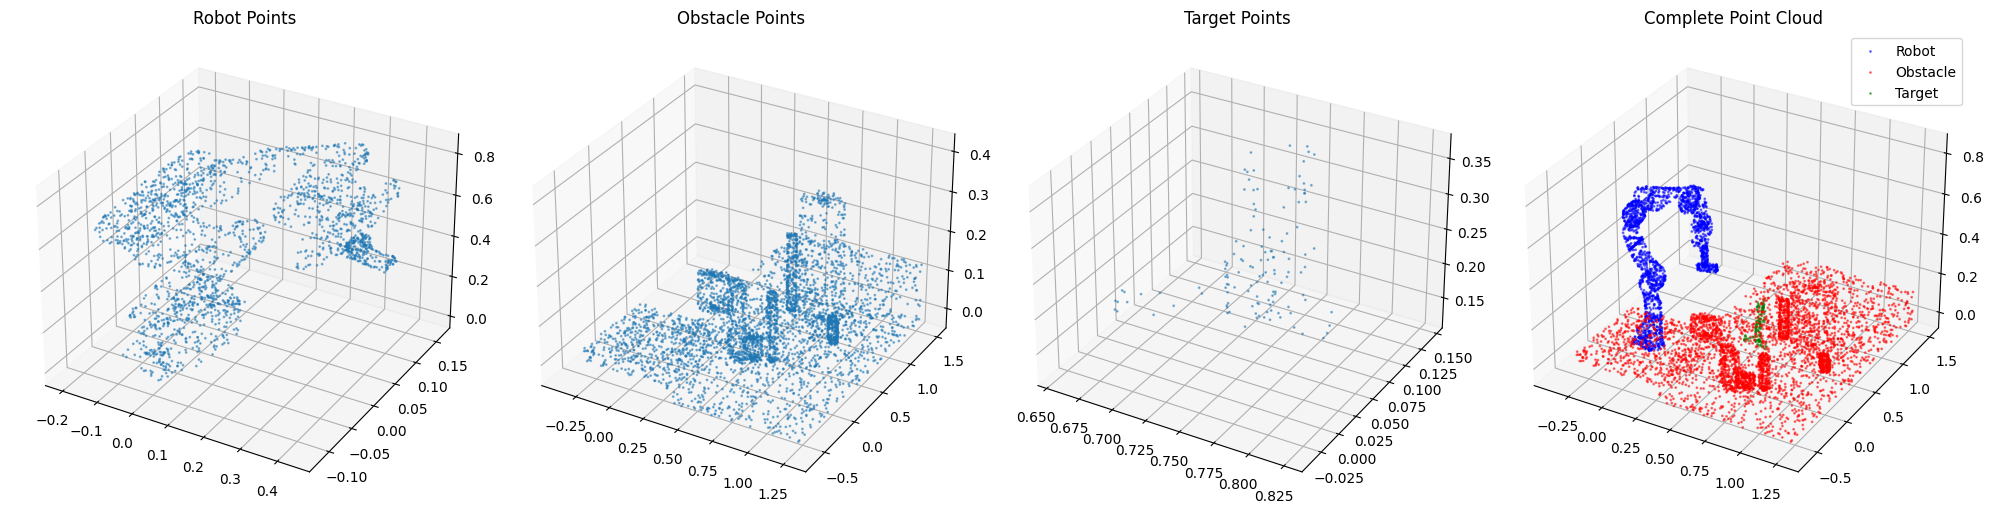

In [20]:
# Optional: Visualize the point clouds
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def visualize_point_clouds(robot_pts, obstacle_pts, target_pts, complete_pc):
    fig = plt.figure(figsize=(20, 5))

    # Robot points
    ax1 = fig.add_subplot(141, projection="3d")
    ax1.scatter(
        robot_pts[:, 0].cpu().numpy(),
        robot_pts[:, 1].cpu().numpy(),
        robot_pts[:, 2].cpu().numpy(),
        s=1,
        alpha=0.5,
    )
    ax1.set_title("Robot Points")

    # Obstacle points
    ax2 = fig.add_subplot(142, projection="3d")
    if len(obstacle_pts) > NUM_OBSTACLE_POINTS:
        sampled_obs = obstacle_pts[
            np.random.choice(
                len(obstacle_pts), min(1000, len(obstacle_pts)), replace=False
            )
        ]
    else:
        sampled_obs = obstacle_pts
    ax2.scatter(sampled_obs[:, 0], sampled_obs[:, 1], sampled_obs[:, 2], s=1, alpha=0.5)
    ax2.set_title("Obstacle Points")

    # Target points
    ax3 = fig.add_subplot(143, projection="3d")
    ax3.scatter(
        target_pts[:, 0].cpu().numpy(),
        target_pts[:, 1].cpu().numpy(),
        target_pts[:, 2].cpu().numpy(),
        s=1,
        alpha=0.5,
    )
    ax3.set_title("Target Points")

    # Complete point cloud
    ax4 = fig.add_subplot(144, projection="3d")
    # Color by label
    robot_mask = complete_pc[:, 3] == 0
    obstacle_mask = complete_pc[:, 3] == 1
    target_mask = complete_pc[:, 3] == 2

    ax4.scatter(
        complete_pc[robot_mask, 0].numpy(),
        complete_pc[robot_mask, 1].numpy(),
        complete_pc[robot_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="blue",
        label="Robot",
    )
    ax4.scatter(
        complete_pc[obstacle_mask, 0].numpy(),
        complete_pc[obstacle_mask, 1].numpy(),
        complete_pc[obstacle_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="red",
        label="Obstacle",
    )
    ax4.scatter(
        complete_pc[target_mask, 0].numpy(),
        complete_pc[target_mask, 1].numpy(),
        complete_pc[target_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="green",
        label="Target",
    )
    ax4.set_title("Complete Point Cloud")
    ax4.legend()

    plt.tight_layout()
    plt.show()


# Visualize
visualize_point_clouds(
    robot_points, obstacle_points, target_points, complete_point_cloud
)

In [ ]:
import open3d as o3d
import numpy as np


def visualize_point_cloud_open3d(point_cloud, camera_pose=None, point_size=5.0, 
                               show_robot=True, show_obstacle=True, show_target=True):
    """
    Visualize point cloud using Open3D with scientific aesthetics.

    Args:
        point_cloud: Tensor or array of shape (N, 4) where last column is label
        camera_pose: Optional camera pose (4x4 matrix)
        point_size: Float, size of the rendered points (default: 5.0)
        show_robot: Boolean, whether to show robot points (default: True)
        show_obstacle: Boolean, whether to show obstacle points (default: True)
        show_target: Boolean, whether to show target points (default: True)
    """
    # --- 1. Data Preparation ---
    if hasattr(point_cloud, "cpu"):
        point_cloud_np = point_cloud.cpu().numpy()
    else:
        point_cloud_np = point_cloud

    # Separate points by label
    robot_points = point_cloud_np[point_cloud_np[:, 3] == 0][:, :3]
    obstacle_points = point_cloud_np[point_cloud_np[:, 3] == 1][:, :3]
    target_points = point_cloud_np[point_cloud_np[:, 3] == 2][:, :3]

    # --- 2. Geometry Creation ---
    geometries = []

    # Scientific Color Palette
    color_robot = [0.45, 0.68, 0.78]      # Muted Light Blue
    color_obstacle = [0.55, 0.57, 0.62]   # Sophisticated Gray
    color_target = [0.85, 0.55, 0.35]     # Muted Orange

    # Create and add robot point cloud if requested
    if show_robot and len(robot_points) > 0:
        pcd_robot = o3d.geometry.PointCloud()
        pcd_robot.points = o3d.utility.Vector3dVector(robot_points)
        pcd_robot.paint_uniform_color(color_robot)
        geometries.append(pcd_robot)

    # Create and add obstacle point cloud if requested
    if show_obstacle and len(obstacle_points) > 0:
        pcd_obstacle = o3d.geometry.PointCloud()
        pcd_obstacle.points = o3d.utility.Vector3dVector(obstacle_points)
        pcd_obstacle.paint_uniform_color(color_obstacle)
        geometries.append(pcd_obstacle)

    # Create and add target point cloud if requested
    if show_target and len(target_points) > 0:
        pcd_target = o3d.geometry.PointCloud()
        pcd_target.points = o3d.utility.Vector3dVector(target_points)
        pcd_target.paint_uniform_color(color_target)
        geometries.append(pcd_target)

    # Check if there are any geometries to display
    if len(geometries) == 0:
        print("Warning: No point cloud data to display with the current filter settings.")
        return

    # --- 3. Visualization Setup ---
    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name="Point Cloud Visualization", width=1024, height=768)

    # Add all selected geometries
    for geometry in geometries:
        vis.add_geometry(geometry)

    # --- 4. Render Options (Aesthetics) ---
    render_option = vis.get_render_option()

    # Set background to White
    render_option.background_color = np.array([1, 1, 1])

    # Set Point Size (Crucial for visibility)
    render_option.point_size = point_size

    # Clean look: hide the coordinate frame axes
    render_option.show_coordinate_frame = False

    # Optional: Turn on lighting for 3D depth perception (makes points look like spheres)
    # render_option.light_on = True

    # --- 5. Camera Control ---
    if camera_pose is not None:
        view_control = vis.get_view_control()
        params = view_control.convert_to_pinhole_camera_parameters()
        # Note: Direct setting of extrinsic might require inverting the matrix
        # depending on your coordinate system conventions (OpenCV vs OpenGL).
        params.extrinsic = camera_pose
        view_control.convert_from_pinhole_camera_parameters(params)

    # Run
    vis.run()
    vis.destroy_window()


# # Example Usage Block (for testing)
# if __name__ == "__main__":
#     # Generate dummy data: 1000 points, x,y,z,label
#     N = 1000
#     points = np.random.rand(N, 4)
#     # Assign random labels (0, 1, 2)
#     points[:, 3] = np.random.randint(0, 3, size=N)

#     # Example 1: Show all categories (default behavior)
#     print("Showing all categories:")
#     visualize_point_cloud_open3d(points, point_size=10.0)
    
#     # Example 2: Show only robot points
#     print("Showing only robot points:")
#     visualize_point_cloud_open3d(points, point_size=10.0, 
#                                show_robot=True, show_obstacle=False, show_target=False)
    
#     # Example 3: Show only target and obstacle
#     print("Showing only target and obstacle points:")
#     visualize_point_cloud_open3d(points, point_size=10.0,
#                                show_robot=False, show_obstacle=True, show_target=True)
    
#     # Example 4: Show only target points
#     print("Showing only target points:")
#     visualize_point_cloud_open3d(points, point_size=10.0,
#                                show_robot=False, show_obstacle=False, show_target=True)

Showing all categories:
Showing only robot points:
Showing only target and obstacle points:
Showing only target points:


In [27]:
import numpy as np
import open3d as o3d


# Get camera pose
camera_pose = ([
    [0.0, -1.0, 0.0, 0.5],
    [0.0, 0.0, 1.0, 0.0],
    [-1.0, 0.0, 0.0, 0.5],
    [0.0, 0.0, 0.0, 1.0],
])#TODO from side view np.array

# Visualize each category one by one
print("Showing Robot points...")
visualize_point_cloud_open3d(complete_point_cloud, camera_pose, point_size=5.0, 
                           show_robot=True, show_obstacle=False, show_target=False)

print("Showing Target points...")
visualize_point_cloud_open3d(complete_point_cloud, camera_pose, point_size=5.0, 
                           show_robot=False, show_obstacle=False, show_target=True)

print("Showing Obstacle points...")
visualize_point_cloud_open3d(complete_point_cloud, camera_pose, point_size=5.0, 
                           show_robot=False, show_obstacle=True, show_target=False)

print("Showing all points together...")
visualize_point_cloud_open3d(complete_point_cloud, camera_pose, point_size=5.0, 
                           show_robot=True, show_obstacle=True, show_target=True)

Showing Robot points...
Showing Target points...
Showing Obstacle points...
Showing all points together...
